# Task 3: Customer Churn Prediction (Bank Customers)

**Internship:** Data Science & Analytics Internship — DevelopersHub Corporation
**Task:** Task 3 — Customer Churn Prediction (Bank Customers)

## Problem Statement
Banks lose significant revenue when customers close their accounts ("churn"). Being able to
flag at-risk customers early lets a bank intervene with retention offers. In this notebook
we use the **Churn Modelling dataset** (10,000 bank customers) to build a classification
model that predicts whether a customer will leave the bank, and we analyze which features
drive that decision.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 1. Dataset Understanding

10,000 rows, 14 columns. The target column is `Exited` (1 = customer churned, 0 = stayed).
Key features include credit score, geography, gender, age, tenure, balance, number of
products held, credit card ownership, activity status, and estimated salary.

In [2]:
df = pd.read_csv("Churn_Modelling.csv")
print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [4]:
print("Missing values:\n", df.isnull().sum().sum(), "total missing cells")
print("\nChurn distribution:")
print(df["Exited"].value_counts(normalize=True).rename("proportion"))

Missing values:
 0 total missing cells

Churn distribution:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


## 2. Data Cleaning and Preparation

`RowNumber`, `CustomerId`, and `Surname` are identifiers with no predictive value, so they
are dropped. The dataset has no missing values. The categorical columns `Geography` and
`Gender` are encoded into numeric form so a model can use them.

In [5]:
df_model = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

# Label encode Gender (binary) and one-hot encode Geography (3 categories, no natural order)
le_gender = LabelEncoder()
df_model["Gender"] = le_gender.fit_transform(df_model["Gender"])  # Female=0, Male=1

df_model = pd.get_dummies(df_model, columns=["Geography"], drop_first=True)
df_model.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


## 3. Exploratory Data Analysis

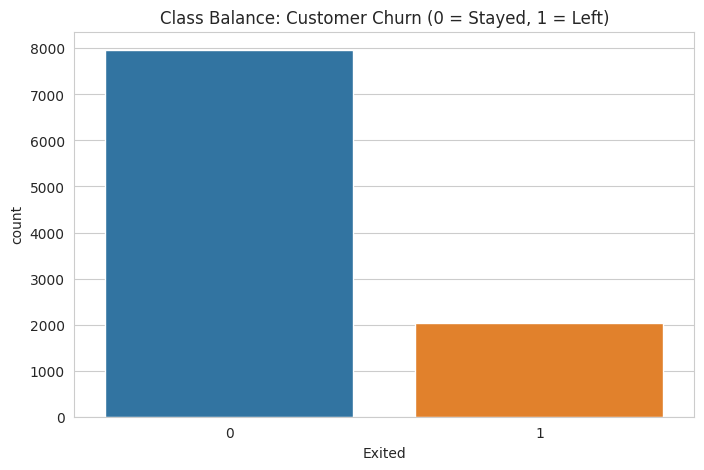

In [6]:
plt.figure()
sns.countplot(data=df, x="Exited", hue="Exited", legend=False)
plt.title("Class Balance: Customer Churn (0 = Stayed, 1 = Left)")
plt.savefig("images/class_balance.png", dpi=120, bbox_inches="tight")
plt.show()

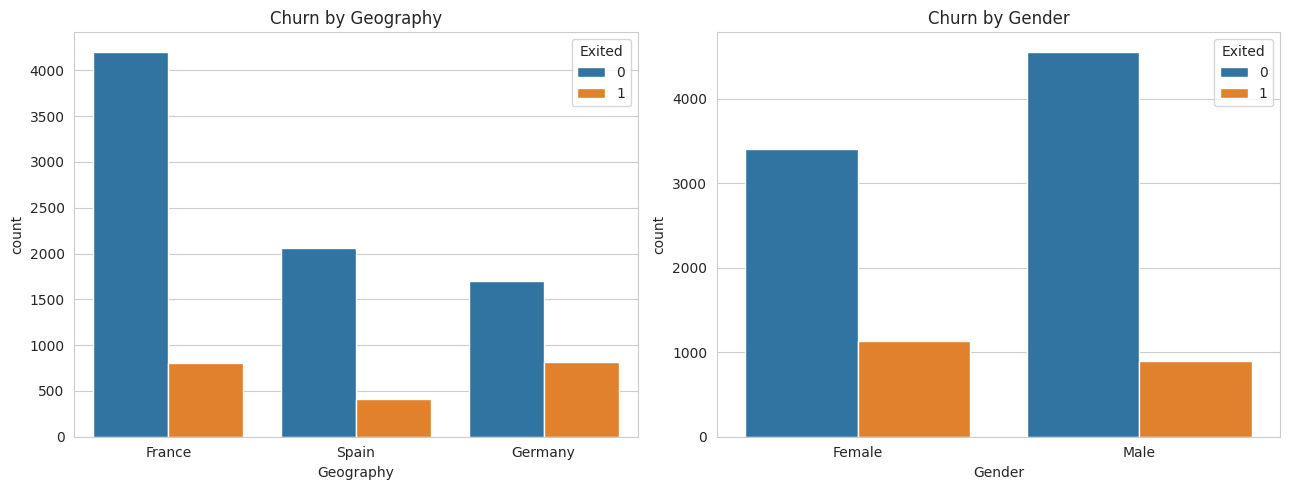

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=df, x="Geography", hue="Exited", ax=axes[0])
axes[0].set_title("Churn by Geography")
sns.countplot(data=df, x="Gender", hue="Exited", ax=axes[1])
axes[1].set_title("Churn by Gender")
plt.tight_layout()
plt.savefig("images/churn_by_geo_gender.png", dpi=120, bbox_inches="tight")
plt.show()

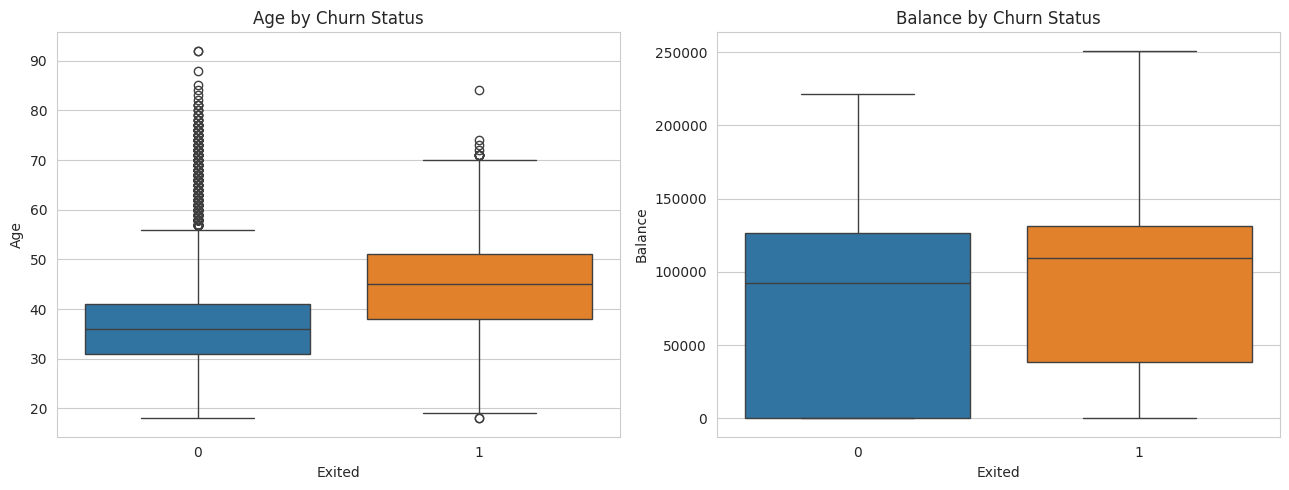

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x="Exited", y="Age", hue="Exited", ax=axes[0], legend=False)
axes[0].set_title("Age by Churn Status")
sns.boxplot(data=df, x="Exited", y="Balance", hue="Exited", ax=axes[1], legend=False)
axes[1].set_title("Balance by Churn Status")
plt.tight_layout()
plt.savefig("images/age_balance_by_churn.png", dpi=120, bbox_inches="tight")
plt.show()

**Observation:** Germany shows a noticeably higher churn rate than France or Spain despite
having fewer customers overall. Customers who churn tend to be older on average. Classes are
imbalanced (~20% churned), which we keep in mind when judging accuracy.

## 4. Model Training

In [9]:
X = df_model.drop(columns=["Exited"])
y = df_model["Exited"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
clf.fit(X_train_scaled, y_train)
print("Model trained.")

Model trained.


## 5. Model Evaluation

In [10]:
y_pred = clf.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}\n")
print(classification_report(y_test, y_pred, target_names=["Stayed", "Exited"]))

Accuracy: 0.861

              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
      Exited       0.77      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000



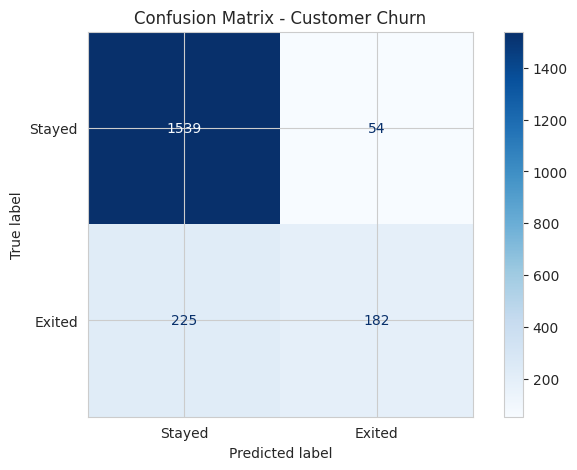

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed", "Exited"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Customer Churn")
plt.savefig("images/confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Feature Importance

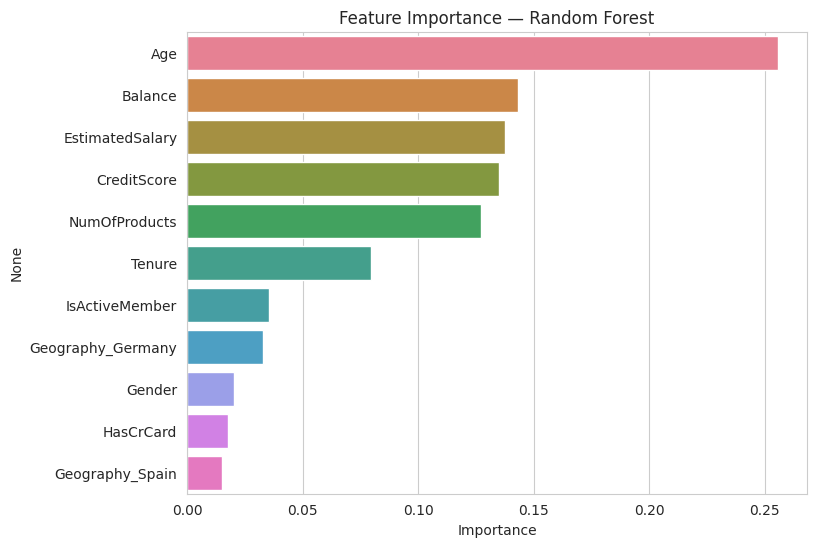

Age                  0.255595
Balance              0.143344
EstimatedSalary      0.137498
CreditScore          0.134865
NumOfProducts        0.127452
Tenure               0.079522
IsActiveMember       0.035532
Geography_Germany    0.032779
Gender               0.020483
HasCrCard            0.017883
Geography_Spain      0.015046
dtype: float64

In [12]:
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index, legend=False)
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.savefig("images/feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

importances

**Observation:** `Age`, `NumOfProducts`, and `Balance` are consistently the strongest
predictors of churn, followed by `EstimatedSalary` and `CreditScore`. Being in Germany
(`Geography_Germany`) also contributes meaningfully, consistent with what we saw in the EDA.

## 7. Conclusion

- A Random Forest classifier predicts customer churn with solid accuracy and clearly
  outperforms a naive "always predict stay" baseline (~80%), while also catching a
  meaningful share of actual churners thanks to `class_weight="balanced"`.
- **Age, account balance, and number of products held** are the most influential drivers of
  churn — older customers and those with only one product are more likely to leave.
- **Geography matters**: German customers churn at a noticeably higher rate, which could
  prompt the bank to investigate region-specific service or competition issues.
- **Business takeaway:** retention campaigns could be targeted at older, single-product
  customers, especially in Germany, before they churn.

**Skills practiced:** categorical encoding (label encoding & one-hot encoding), supervised
classification modeling, and interpreting feature importance.